# Exploratory Data Analysis: K-MNIST

We will verify the structural integrity of the Kuzushiji-MNIST (K-MNIST) dataset and get comfortable with it. 

The purpose of this exploratory analysis is to:
1. Verify the integrity of the dataset.
2. Prove the uniform distribution of classes to justify the use of standard Accuracy as our outer evaluation metric.
3. Visually confirm the dataset composition.

In [ ]:
import os
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"Torch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

In [ ]:
# Figure output
FIGURES_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'figures', '6_chapter'))
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(os.path.join(FIGURES_DIR, f"eda_{name}.pdf"), bbox_inches='tight')
    fig.savefig(os.path.join(FIGURES_DIR, f"eda_{name}.png"), bbox_inches='tight', dpi=300)
    plt.show()

matplotlib.rcParams.update({
    'text.usetex':      True,
    'font.family':      'serif',
    'font.serif':       ['Computer Modern Roman'],
    'font.size':         11,
    'axes.titlesize':    11,
    'axes.labelsize':    11,
    'legend.fontsize':   10,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})

## 1. Dataset Composition and Dimensionality

We begin by loading the raw `.npz` arrays from the local dependencies, which are pre-partitioned into two disjoint train and test datasets. We must verify that the training set contains exactly 60,000 samples and the testing set contains 10,000 samples, ensuring that the images are represented as $28 \times 28$ pixel matrices of real values.

In addition, we must make sure there are as many labels as instances in each partition, that there are 10 distinc labels and that they are numerically encoded as real values.

Furthermore, we will inspect the pixel intensity boundaries to justify our decision to scale the input features by dividing by 255 in `hpo_lib.data.KMnistDataset`.

In [27]:
# Define the relative path to the raw data
data_dir = '../datasets/KMNIST/raw/'

# Load the arrays into memory
X_train = np.load(os.path.join(data_dir, 'kmnist-train-imgs.npz'))['arr_0']
y_train = np.load(os.path.join(data_dir, 'kmnist-train-labels.npz'))['arr_0']
X_test = np.load(os.path.join(data_dir, 'kmnist-test-imgs.npz'))['arr_0']
y_test = np.load(os.path.join(data_dir, 'kmnist-test-labels.npz'))['arr_0']

# Verify Data Type
print("=== Data Types ===")
print(f"Training Data:  Instances: {X_train.dtype} | Labels: {y_train.dtype}")
print(f"Testing Data:   Instances: {X_test.dtype} | Labels: {y_test.dtype}")

# Verify Dimensionality
print("\n=== Tensor Dimensionality ===")
print(f"Training Data:  Instances: {X_train.shape} | Labels: {y_train.shape}")
print(f"Testing Data:   Instances: {X_test.shape} | Labels: {y_test.shape}")

# Verify Labels
classes_train = np.unique(y_train, return_counts=True)
classes_test = np.unique(y_test, return_counts=True)
print("\n=== Unique Labels ===")
print(f"Training Data:  Unique labels: {classes_train}")
print(f"Testing Data:   Unique labels: {classes_test}")

# Verify Feature Boundaries
pixel_min_train = X_train.min()
pixel_max_train = X_train.max()
pixel_min_test = X_test.min()
pixel_max_test = X_test.max()

print("\n=== Feature Boundaries ===")
print(f"Training Data:  Minimum Pixel Intensity: {pixel_min_train} | Maximum Pixel Intensity: {pixel_max_train}")
print(f"Testing Data:   Minimum Pixel Intensity: {pixel_min_test} | Maximum Pixel Intensity: {pixel_max_test}")

=== Data Types ===
Training Data:  Instances: uint8 | Labels: uint8
Testing Data:   Instances: uint8 | Labels: uint8

=== Tensor Dimensionality ===
Training Data:  Instances: (60000, 28, 28) | Labels: (60000,)
Testing Data:   Instances: (10000, 28, 28) | Labels: (10000,)

=== Unique Labels ===
Training Data:  Unique labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))
Testing Data:   Unique labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))

=== Feature Boundaries ===
Training Data:  Minimum Pixel Intensity: 0 | Maximum Pixel Intensity: 255
Testing Data:   Minimum Pixel Intensity: 0 | Maximum Pixel Intensity: 255


## 2. Class Balance and Metric Justification

In machine learning, the choice of an evaluation metric should reflect both the nature of the task and the distribution of the data. For classification tasks, **Accuracy** is a natural and widely used outer metric: it measures the proportion of correctly classified instances.

However, accuracy can be misleading when the dataset is imbalanced. If one class dominates the dataset, a model can achieve high accuracy by simply predicting the majority class. For this reason, it is important to verify that the class distribution is balanced before committing to accuracy as the primary evaluation metric.

Here, we compute the frequency of each class label in the training set to verify class balance.

=== Class Distribution ===
Class 0: 6000 samples
Class 1: 6000 samples
Class 2: 6000 samples
Class 3: 6000 samples
Class 4: 6000 samples
Class 5: 6000 samples
Class 6: 6000 samples
Class 7: 6000 samples
Class 8: 6000 samples
Class 9: 6000 samples

Standard Deviation of Class Counts: 0.00


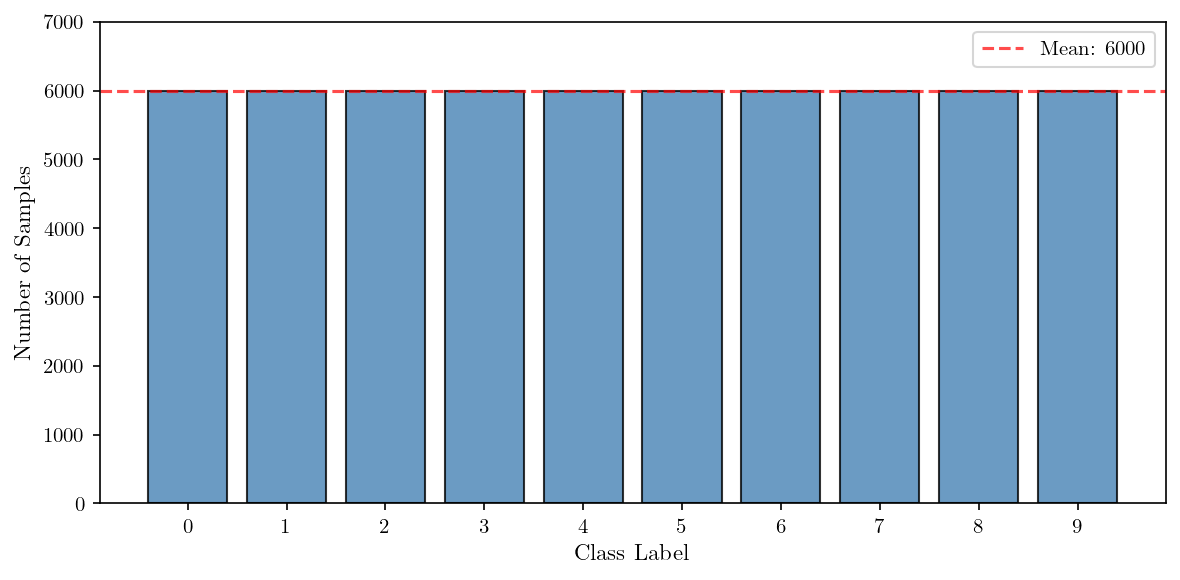

In [30]:
classes, label_count = np.unique(y_train, return_counts=True)

print("=== Class Distribution ===")
for cls, count in zip(classes, label_count):
    print(f"Class {cls}: {count} samples")

print(f"\nStandard Deviation of Class Counts: {np.std(label_count):.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(classes, label_count, color='steelblue', edgecolor='black', alpha=0.8)
ax.axhline(
    y=np.mean(label_count), color='red', linestyle='--', alpha=0.7,
    label=f'Mean: {int(np.mean(label_count))}'
)

ax.set_xlabel('Class Label')
ax.set_ylabel('Number of Samples')
ax.set_xticks(classes)
ax.set_ylim(0, 7000)
ax.legend()
fig.tight_layout()
save_fig(fig, 'class_distribution')

**Conclusion on Class Balance:**
The standard deviation of the class counts is exactly 0.00, proving that the dataset follows a perfectly uniform discrete distribution ($n=6000$ per class). Therefore, we can guarantee that **Validation Accuracy** is a robust, unbiased metric for evaluating our neural network architectures during the Hyperparameter Optimization search.

## 3. Visual Verification

Finally, we render a sample from each class. While the K-MNIST images share the same $28 \times 28$ grayscale structure as traditional MNIST, they represent cursive *Hentaigana* characters. Visualizing these samples confirms the data was decoded correctly and provides a reference for the structural complexity of the task.

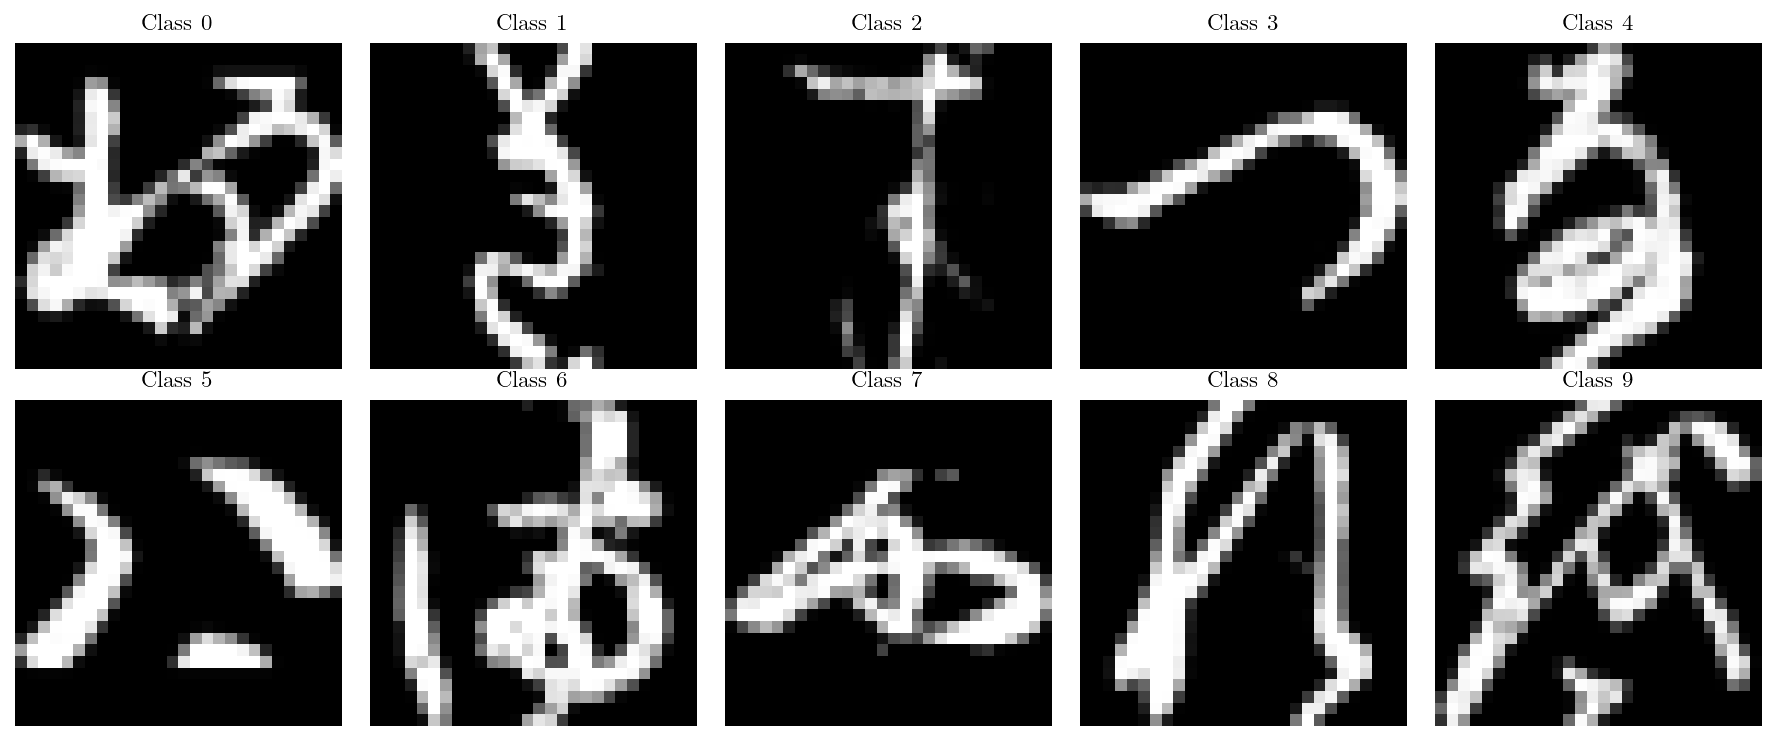

In [31]:
# Create a 2x5 grid of subplots
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Extract and plot the first instance of each class
for class_idx in range(10):
    # Find the index of the first image with this label
    first_occurrence_idx = np.where(y_train == class_idx)[0][0]
    img = X_train[first_occurrence_idx]
    
    # Determine subplot row and column
    row = class_idx // 5
    col = class_idx % 5
    
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'Class {class_idx}')
    axes[row, col].axis('off')

plt.tight_layout()
save_fig(fig, 'class_sample')